# **Face verification system by Principal Component Analysis (PCA)**

## **The face database**

For this homework we will work on face verification (Given a face, say whether it is person A or
not). Face verification is quite related to face recognition (Given a face, say who it is). Face
verification is a binary classification task, while face recognition is a multi-class problem.
Download the file “facedata.mat”. You can load the data by

In [2]:
import scipy.io
import numpy as np

### Load & Play data

In [7]:
data = scipy.io.loadmat('facedata.mat')
# face data is a 2-dimensional array with size 40x10
print(data['facedata'].shape) # 40 person, 10 pose

(40, 10)


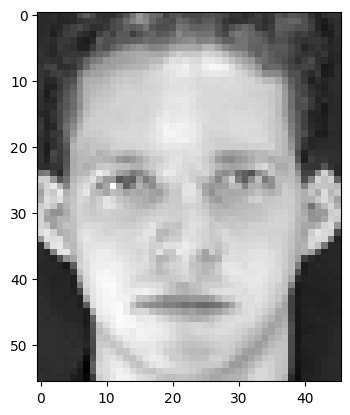

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(data['facedata'][0,0],cmap="gray")
plt.show()

In [9]:
from skimage import img_as_float
xf = {}
xf[0,0] = img_as_float(data['facedata'][0,0])
print(f"image shape:{xf[0,0].shape}")

image shape:(56, 46)


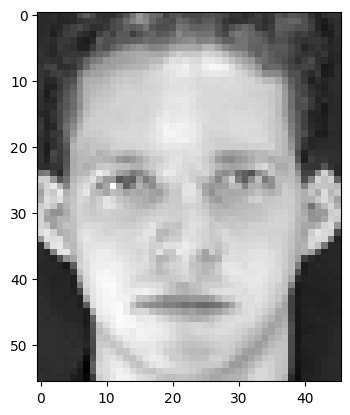

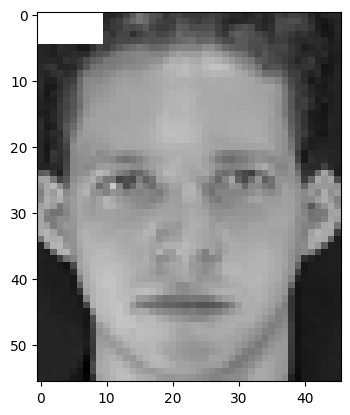

In [10]:
plt.imshow(xf[0,0],cmap="gray")
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
# In float format, 1 is white
plt.imshow(x_temp,cmap="gray")
plt.show()

### **Part 1**

What is the Euclidean distance between xf[0,0] and xf[0,1]? What is the Euclidean
distance between xf[0,0] and xf[1,0]? Does the numbers make sense? Do you think these numbers
will be useful for face verification? Why?

In [63]:
xf1 = {}
xf1[0,0] = img_as_float(data['facedata'][0,0])
xf1[1,0] = img_as_float(data['facedata'][1,0])

img0 = xf1[0,0] #.reshape(-1)
img1 = xf1[1,0] #.reshape(-1)
# print(img0.shape) # 2576

similarity = np.sqrt(np.sum((img0 - img1)**2))
print(f"Similarity (Euclidean distance) [0,0] to [1,0]: {similarity}")


xf1[0,1] = img_as_float(data['facedata'][0,1])

img3 = xf1[0,0] #.reshape(-1)
img4 = xf1[0,1] #.reshape(-1)
# print(img0.shape) # 2576

similarity2 = np.sqrt(np.sum((img3 - img4)**2))
print(f"Similarity (Euclidean distance) [0,0] to [0,1]: {similarity2}")

Similarity (Euclidean distance) [0,0] to [1,0]: 8.173295099737281
Similarity (Euclidean distance) [0,0] to [0,1]: 10.037616294165492


#### **Answer**
- Distance between $xf[0,0]$ and $xf[1,0]$ is **`8.173295099737281`**
- Distance between $xf[0,0]$ and $xf[0,1]$ is **`10.0376162941654921`**

- **`No`** this number only show the distance between the picture, but in face verification should be consider the face structure, which not the point to point distance. It should consider the main feature such as the `eye`, `mouth`, `ear` or etc. On the same way, less distance do not mean that the image is the same as the face.
- $xf[0,0]$ and $xf[0,1]$ is the same person but it got higher similarity than the  $xf[0,0]$ and $xf[1,0]$, which not the same person


### **Part 2**

As we continue our exercise, we will refine our feature vectors so that the Euclidean distance
between two images can be used in a face verification system.

We define the similarity matrix, $A$, as a matrix whose elements $A_{i,j}$ is the Euclidean distance
between data sample $i$ from list $T$ and data sample $j$ from list $D$, where list $T$,$D$ are lists of data
samples.

**Write a function that takes in a set of feature vectors $T$ and a set of feature vectors $D$, and then output the similarity matrix $A$**. Show the matrix as an image. Use the feature vectors from the first 3 images from all 40 people for list $T$ (in order x[0, 0], x[0, 1], x[0, 2], x[1, 0], x[1, 1],
...x[39, 2]). Use the feature vectors from the remaining 7 images from all 40 people for list $D$ (in
order x[0, 3], x[0, 4], x[0, 5], x[1, 6], x[0, 7], x[0, 8], x[0, 9], x[1, 3], x[1, 4]...x[39, 9]). We will treat
$T$ as our training images and $D$ as our testing images.

In [7]:
xf2_full = {}
for people in range(40):
    for pose in range(10):
        xf2_full[people, pose] = img_as_float(data['facedata'][people, pose])

In [89]:
num_people = 40
num_train_pose = 3
num_test_pose = 7
N = num_people * num_train_pose
D = 56 * 46

xf2_train = {}
xf2_test = {}
for people in range(num_people):
    for pose in range(num_train_pose):
        xf2_train[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf2_test[people, pose] = img_as_float(data['facedata'][people, pose])

#### **Answer**

In [153]:
def similarity_matrix(T,D):
    """ Calculating the simlarity of matrix T and D with euclidean distance """
    # A = np.sqrt(np.sum((T - D)**2))
    A = np.linalg.norm(T - D)
    return A

- example run of our code

In [10]:
A = similarity_matrix(T=xf2_full[0,0] , D=xf2_full[1,0])
print(f"Similarity: {A}")

Similarity: 8.173295099737281


In our simple face verification system, given a test image, we want to test if that image comes from person A or not. We will compare the test image against the three training images from person $A$ we have. If the minimum distance (between the three training images) is below a threshold, $t$, we say that the test image is person $A$.

In [11]:
target_A = 0
threshold = 10

for i in range(3):
    dist = similarity_matrix(T=xf2_train[target_A,i] , D=xf2_test[target_A,0])
    if dist < threshold:
        print("This is Person A!")
        break
    else:
        print("This is not Person A!")

This is Person A!


### **Part 3**

**Write a function that takes in the similarity matrix created from the previous part**, and a threshold $t$ as inputs. The outputs of the function are the true positive rate and the false alarm rate of the face verification task (280 Test images, tested on 40 people). What is the true
positive rate and the false alarm rate for $t = 10$? (5 points)

In [172]:
sim = np.zeros((280,num_people,num_train_pose)) # [test figure, train person, train pose]

for num_fig,test_dict in enumerate(xf2_test):
    for check_people in range(num_people):
        for check_pose in range(num_train_pose):
            sim[num_fig, check_people, check_pose] = similarity_matrix(xf2_test[test_dict] , xf2_train[check_people,check_pose])

In [186]:
def face_verification(similarity, t):
    '''
    similarity: the similarity score between the test image and the training image
    t: the threshold for verification
    '''
    TP = 0 ; TN = 0
    FP = 0 ; FN = 0
    
    shape_image , person , pose = similarity.shape
    for image in range(shape_image):
        for check_person in range(person):
            for check_pose in range(pose):
                if similarity[image, check_person, check_pose] < t:
                    if check_person == image//(shape_image/person):
                        TP += 1
                    else:
                        FP += 1
                else:
                    if check_person == image//(shape_image/person):
                        FN += 1
                    else:
                        TN += 1
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
    result = {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TPR": TPR,
        "FAR": FAR
    }
    return result

In [175]:
result = face_verification(similarity=sim, t=10)
print(f"True Positive Rate: {result['TPR']}")
print(f"False Alarm Rate: {result['FAR']}")
print(f"TP: {result['TP']}, TN: {result['TN']}, FP: {result['FP']}, FN: {result['FN']}")
print(f"Result: {result}")

True Positive Rate: 0.9761904761904762
False Alarm Rate: 0.35482295482295484
TP: 820, TN: 21136, FP: 11624, FN: 20
Result: {'TP': 820, 'TN': 21136, 'FP': 11624, 'FN': 20, 'TPR': 0.9761904761904762, 'FAR': 0.35482295482295484}


### **Part 4**
Plot the RoC curve (curve between the true positive rate (TP) as y-axis and the false alarm rate (false positive rate or FP) as x-axis) for this simple verification system when threshold changes. What should be the minimum threshold to generate the RoC curve? What should be the maximum threshold? Your RoC should be generated from at least 1000 threshold levels equally spaced between the minimum and the maximum. (You should write a function for this).

In [15]:
num_thresholds = 1000
# thresholds = np.linspace(1.5, 15, num_thresholds)
thresholds = np.linspace(0, 15, num_thresholds)
tpr = np.array([])
far = np.array([])
# tpr = np.zeros()
# far = np.zeros()

for i, t in enumerate(thresholds):
    result = face_verification(similarity=sim, t=t)
    # tpr[i] = result['TPR']
    # far[i] = result['FAR']
    tpr = np.append(tpr, result['TPR'])
    far = np.append(far, result['FAR'])
    # print(f"Threshold: {i}, TPR: {result['TPR']}, FAR: {result['FAR']}")

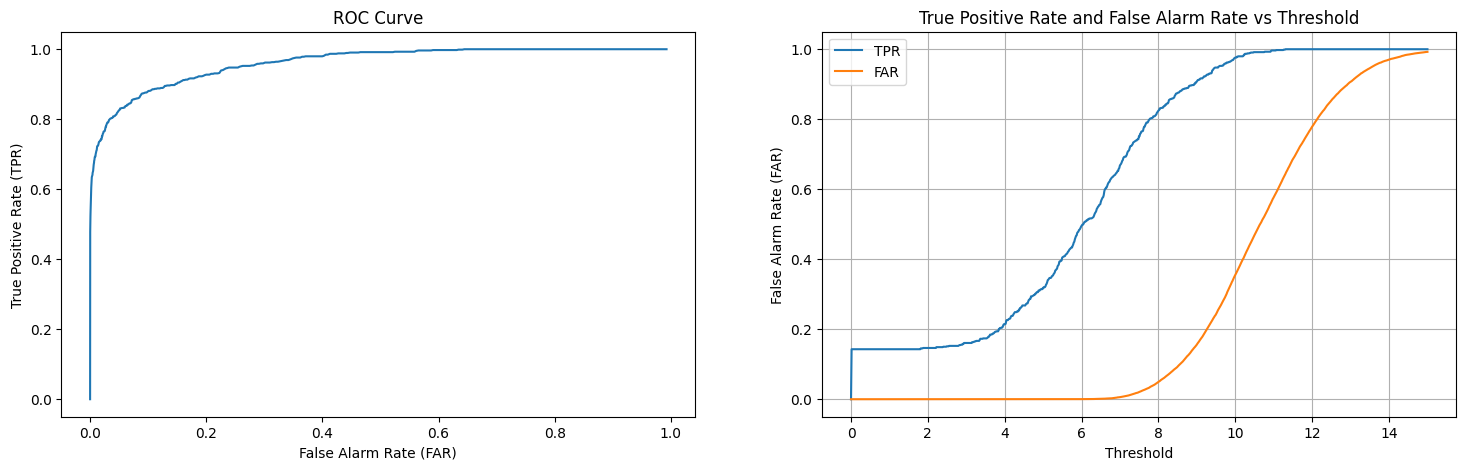

In [16]:
plt.figure(figsize=(18, 5))
# plt.plot(false_alarm_rate, true_positive_rate, marker='o')
plt.subplot(1, 2, 1)
plt.plot(far, tpr)
plt.title('ROC Curve')
plt.xlabel('False Alarm Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')


plt.subplot(1, 2, 2)
plt.plot(thresholds, tpr, label='TPR')
plt.plot(thresholds, far, label='FAR')
plt.title('True Positive Rate and False Alarm Rate vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('False Alarm Rate (FAR)')
plt.legend()


plt.grid()
plt.show()

Closest point:
FAR = 0.11391941391941392
TPR = 0.8869047619047619
Threshold = 8.67867867867868


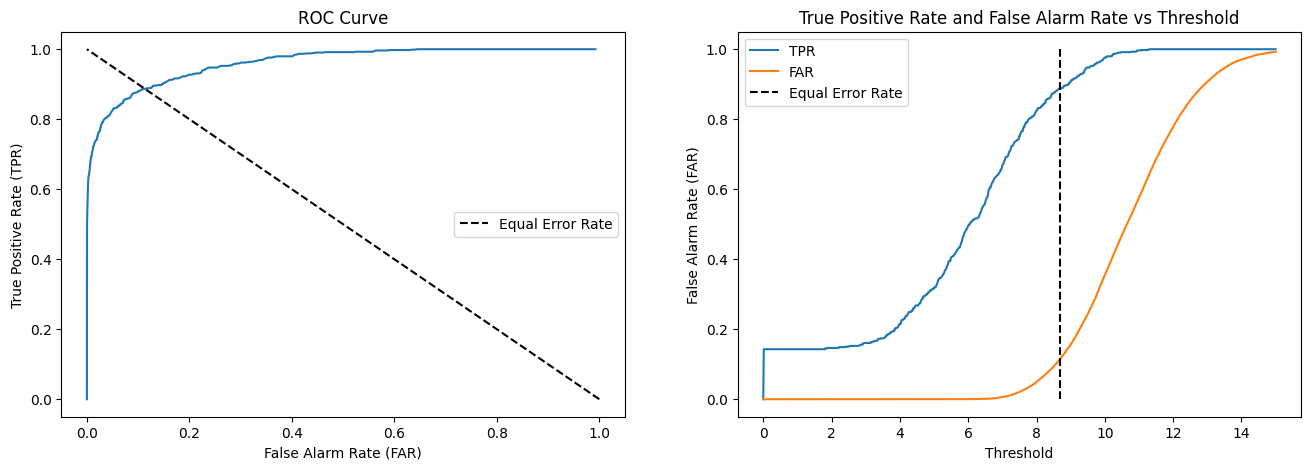

In [17]:
plt.figure(figsize=(16, 5))
# plt.plot(false_alarm_rate, true_positive_rate, marker='o')
plt.subplot(1, 2, 1)
plt.plot(far, tpr)
plt.plot([1, 0], [0, 1], 'k--', label='Equal Error Rate')
plt.title('ROC Curve')
plt.xlabel('False Alarm Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

dist_to_line = np.abs(tpr - (1 - far)) / np.sqrt(2)
idx = np.argmin(dist_to_line)

plt.subplot(1, 2, 2)
plt.plot(thresholds, tpr, label='TPR')
plt.plot(thresholds, far, label='FAR')
plt.plot([thresholds[idx], thresholds[idx]], [0, 1], 'k--', label='Equal Error Rate')
plt.title('True Positive Rate and False Alarm Rate vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('False Alarm Rate (FAR)')
plt.legend()

print("Closest point:")
print("FAR =", far[idx])
print("TPR =", tpr[idx])
print("Threshold =", thresholds[idx])

- True Positive Rate (TPR) : classifier `tell True correctly` (given the all True)
- False Alarm Rate (FAR) : classifier `tell True`, `but it False`

#### Answer
The Closest point is on
- TPR(y) = 0.8869047619047619
- FAR(x) = 0.11391941391941392
We can get the **`Threshold = 8.67867867867868`** and we will get TPR = 0.8869 that mean our classifier can predict correctly if our classifier meet the right person with success rate 88.69%. On the other hand, FAR = 0.1139 show that our model classify wrong for 11.39% if the target is not the same as label. 

#### Answer 2

This means that when the threshold is set to 8.6787, the face verification system correctly accepts genuine matches 88.69% of the time. In other words, if the test image truly belongs to the claimed person, the system will verify it correctly with a true positive rate of 88.69%.

At the same time, the system incorrectly accepts impostor matches 11.39% of the time. That is, when the test image does not belong to the claimed person, the system still falsely verifies it as a match with a false alarm rate of 11.39%.

Therefore, this threshold provides a reasonable trade-off between correctly recognizing genuine users and limiting false acceptances.

## **Principle Component Analysis (PCA)**

PCA is a method for dimensionality reduction that is very flexible and fits many use cases. It is unsupervised (needs no class label). The core of PCA is using eigendecomposition to decompose the data into the directions of maximum variance.

Let’s define a matrix $X$ with each column as an input sample $\vec{x}_i$.

A typical PCA starts by normalizing each feature dimension so that they have equal range. For
our case, since our input vectors are already between 0 and 1, we can skip this step.
The first step of PCA is to first remove the global mean from our data. Let $\vec{\mu}_x$ be the means of the
input data along each input dimension. Let $\hat{X}$ be the matrix with the mean of the input samples
removed. Be sure to use the mean computed from just the training examples.

### **Part 5**

Compute the mean vector from the training images. Show the vector as an image (use `numpy.reshape()`). This is typically called the meanface (or meanvoice for speech signals). And
plot the meanface by `imshow` command. (2 points)

In [88]:
num_people = 40
num_train_pose = 3
num_test_pose = 7
D = 56 * 46
N = num_people * num_train_pose

xf5_train = {}
xf5_test = {}
for people in range(num_people):
    for pose in range(num_train_pose):
        xf5_train[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf5_test[people, pose] = img_as_float(data['facedata'][people, pose])

In [12]:
train_mean_flat = np.zeros((num_people,56*46))
for i, figure in enumerate(xf5_train.keys()):   
    train_mean_flat[i//num_train_pose] +=  np.reshape(xf5_train[figure],shape=(-1,))
train_mean_flat /= num_train_pose

train_mean = train_mean_flat.reshape(num_people, 56, 46)

#### **Answer**

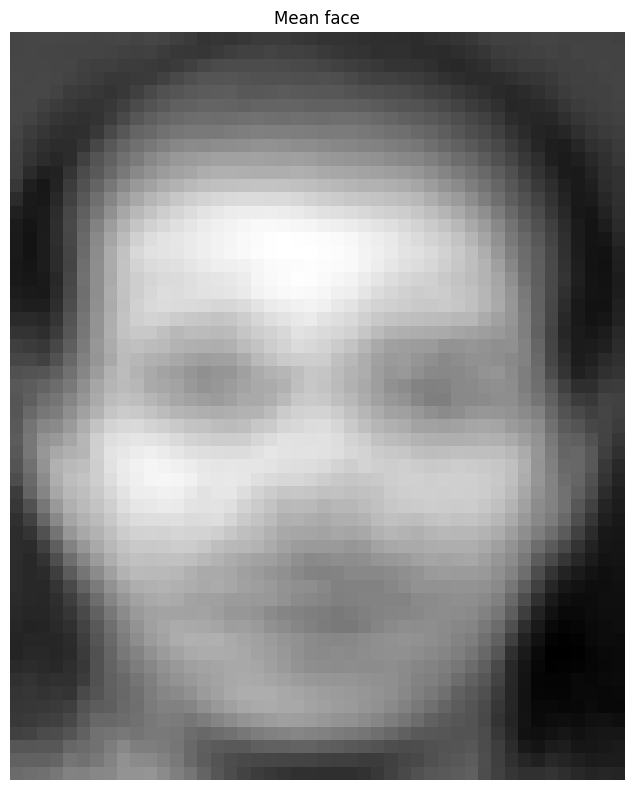

In [ ]:

# Build data matrix: one row = one image
X = np.zeros((N, D))

idx = 0
for i in range(num_people):
    for j in range(num_train_pose):
        X[idx] = xf5_train[i, j].reshape(-1)
        idx += 1
# Global mean face
mean_face = np.mean(X, axis=0)   # shape (D,)

plt.figure(figsize=(12, 8))
plt.imshow(mean_face.reshape(56, 46), cmap="gray")
plt.title(f"Mean face", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

We can then compute eigenvectors on the covariance matrix computed from $\hat{X}$. The PCA vectors
would correspond to the eigenvectors, $\vec{v}$. In other words, $\sum v$ = $\lambda \vec{v}$.
However, if we compute the covariance matrix, we would need a lot of space to store it.

### **Part 6**
What is the size of the covariance matrix? What is the rank of the covariance matrix?

In [14]:
train_mean_flat6 = train_mean_flat.copy()
num_per_person = 3
xf6_train = xf5_train.copy()
xf6_test = xf5_test.copy()

In [ ]:
# Build data matrix: one row = one image
X = np.zeros((N, D))

idx = 0
for i in range(num_people):
    for j in range(num_train_pose):
        X[idx] = xf6_train[i, j].reshape(-1)
        idx += 1
# Global mean face
mean_face = np.mean(X, axis=0)   # shape (D,)
# Center all images
x_center = X - mean_face       # shape (N, D)
# Covariance matrix
cov = (x_center.T @ x_center) / (N - 1)   # shape (D, D)

In [67]:
print(f"Covariance matrix shape: {cov.shape}")

Covariance matrix shape: (2576, 2576)


In [78]:
skip = False
r = np.linalg.matrix_rank(cov)
print(f"Person {i}: rank = {r}")

Person 1: rank = 119


#### **Answer**
- `Covariance matrix Size` : size of covariance matrix is depending on number of feature in dataset, in our task we has 3 image per person, and each image has dimension $56*46$ dimension, so we have covariance matrix size = **`2576 x 2576`** for each person
- `Covariance matrix Rank` : For one person, we have:
    -  num_train_pose = m
    - covariance built from m centered samples
    - then the rank is at most:
    $$rank(C) \le m-1$$
    - Rank of Covariance matrix also depending on number of training dataset that we have only 120 sample, so we have only **`rank = 120-1 = 119`**, subtract 1 from mean image.

The trick is to compute the Gram Matrix $(X̂^TX̂)$, which is the inner product between the input matrices.

### **Part 7**

What is the size of the Gram matrix? What is the rank of Gram matrix? If we compute the eigenvalues from the Gram matrix, how many non- zero eigenvalues do we expect to get?

- from the shape of $\hat{X}$ is $N \times D$, so that $\hat{X}^T$ is $D \times N$

In [81]:
# Build data matrix
X = np.zeros((N, D))
idx = 0
for i in range(num_people):
    for j in range(num_train_pose):
        X[idx] = xf6_train[i, j].reshape(-1)
        idx += 1
mean_face = np.mean(X, axis=0)
X_centered = X - mean_face
# Gram matrix
G = X_centered @ X_centered.T    # shape (N, N)

In [ ]:
# for i in range(num_people):
r_ = np.linalg.matrix_rank(G)
print(f"Person {i}: rank = {r} | dim(G) = {G.shape}")

Person 39: rank = 119 | dim(G) = (120, 120)


#### **Answer**
- `Gram matrix Size` : size of Gram matrix is depending on number of traning data which is 3 sample per person, which is the inner product between the input
matrices. The dimension of this matrix is `N x N` -> **`120 x 120`** per person

- `Gram matrix Rank` : the rank of gram matrix is also the same as the covariance matrix, which is `2`
$$rank(G)=rank(X_{center})\le \min{(N-1,D)}$$

- `How many eigen value` : the number of non-zero eigen value is corresponding to the $x_{center}$, which is has dimension = $120 \times 120$, the non-zero eigen value will be $N-1$ = **$119$**,

### **Part 8**
Is the Gram matrix also symmetric? Why?

In [ ]:
is_symmetric_1 = np.array_equal(G, G.T)
print(f"Is the Gram matrix symmetric? : {is_symmetric_1}")

Is the Gram matrix symmetric? True


#### **Answer**
- `True` : the Gram matrix is symmetry, we checking with using the function `np.array_equal` and check with Gram matrix and Gram matrix transpose.
- `Why` : this is the tranpose matrix properties!

$$G=XX^T$$
$$G^T=(XX^T)^T$$
so that,
$$(AB)^T=B^TA^T$$
then,
$$G^T=(X^T)^TX^T=XX^T=G$$

### **Part 9**
Compute the eigenvectors and eigenvalues of the Gram matrix, $\vec{v}'$ and $\lambda$. Sort the
eigenvalues and eigenvectors in descending order so that the first eigenvalue is the highest, and
the first eigenvector corresponds to the best direction. How many non-zero eigenvalues are there?
If you see a very small value, it is just numerical error and should be treated as zero.

In [102]:
eigenvalues, eigenvectors = np.linalg.eigh(G)

# sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Check that all eigenvector has non-zero eigen value

In [105]:
print(f"Sorted eigenvectors: {eigenvectors}")

Sorted eigenvectors: [[ 0.07820028 -0.08144841  0.16838572 ... -0.03284951  0.01171851
  -0.09128709]
 [ 0.15633363 -0.06891888  0.00607299 ... -0.00712131  0.00347436
  -0.09128709]
 [ 0.14076739 -0.04460943  0.08922514 ...  0.03802993  0.01301747
  -0.09128709]
 ...
 [ 0.03542524 -0.08254825 -0.13635891 ... -0.01356318  0.00197116
  -0.09128709]
 [ 0.04815903 -0.11167625 -0.06627051 ... -0.03108812 -0.02639082
  -0.09128709]
 [ 0.04395375 -0.12893456 -0.07990511 ...  0.02085834  0.01616482
  -0.09128709]]


In [104]:
tol = 1e-8
for i, val in enumerate(eigenvalues):
    if val > tol:
        print(f"Eigenvector {i}: NON-ZERO eigenvalue ({val:.4e})")
    else:
        print(f"Eigenvector {i}: ZERO (or near zero)")

Eigenvector 0: NON-ZERO eigenvalue (1.4239e+03)
Eigenvector 1: NON-ZERO eigenvalue (8.7538e+02)
Eigenvector 2: NON-ZERO eigenvalue (5.5862e+02)
Eigenvector 3: NON-ZERO eigenvalue (4.0735e+02)
Eigenvector 4: NON-ZERO eigenvalue (3.7102e+02)
Eigenvector 5: NON-ZERO eigenvalue (2.6328e+02)
Eigenvector 6: NON-ZERO eigenvalue (2.0340e+02)
Eigenvector 7: NON-ZERO eigenvalue (1.9097e+02)
Eigenvector 8: NON-ZERO eigenvalue (1.6655e+02)
Eigenvector 9: NON-ZERO eigenvalue (1.4357e+02)
Eigenvector 10: NON-ZERO eigenvalue (1.2295e+02)
Eigenvector 11: NON-ZERO eigenvalue (1.0479e+02)
Eigenvector 12: NON-ZERO eigenvalue (9.3661e+01)
Eigenvector 13: NON-ZERO eigenvalue (8.5202e+01)
Eigenvector 14: NON-ZERO eigenvalue (8.0079e+01)
Eigenvector 15: NON-ZERO eigenvalue (7.2293e+01)
Eigenvector 16: NON-ZERO eigenvalue (6.9290e+01)
Eigenvector 17: NON-ZERO eigenvalue (6.5556e+01)
Eigenvector 18: NON-ZERO eigenvalue (6.1679e+01)
Eigenvector 19: NON-ZERO eigenvalue (5.9074e+01)
Eigenvector 20: NON-ZERO eigen

#### **Answer**
- Their is `1` eigen value that is zero-eigen value, which is happen from subtract the mean out!, that is the last eigenvector

### **Part 10**
Plot the eigenvalues. Observe how fast the eigenvalues decrease. In class, we learned that the eigenvalues are the size of the variance for each eigenvector direction. If I want to keep 95% of the variance in the data, how many eigenvectors should I use? The plot example is shown below.

Number of eigenvectors for 95% variance: 64


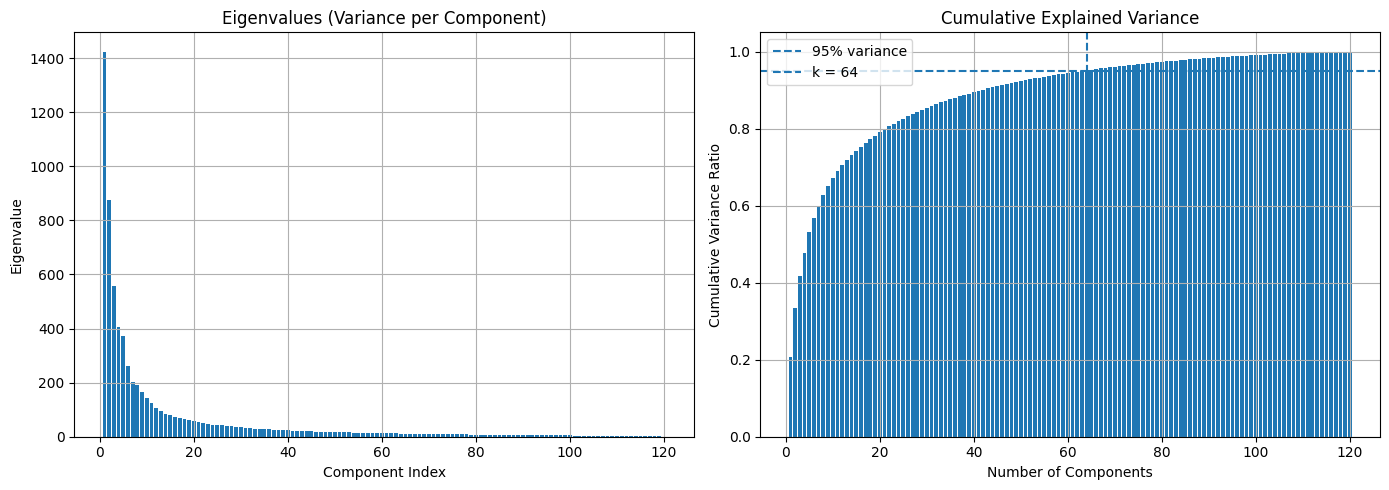

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# eigenvalues already sorted (descending)
lam = np.maximum(eigenvalues, 0)

# explained variance
explained_ratio = lam / np.sum(lam)
cumvar = np.cumsum(explained_ratio)

# find k for 95%
k95 = np.argmax(cumvar >= 0.95) + 1
print("Number of eigenvectors for 95% variance:", k95)

# ---- plotting ----
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# (1) eigenvalues bar chart
axs[0].bar(np.arange(1, len(lam)+1), lam)
axs[0].set_title("Eigenvalues (Variance per Component)")
axs[0].set_xlabel("Component Index")
axs[0].set_ylabel("Eigenvalue")
axs[0].grid(True)

# (2) cumulative variance bar chart
axs[1].bar(np.arange(1, len(cumvar)+1), cumvar)
axs[1].axhline(0.95, linestyle='--', label='95% variance')
axs[1].axvline(k95, linestyle='--', label=f'k = {k95}')
axs[1].set_title("Cumulative Explained Variance")
axs[1].set_xlabel("Number of Components")
axs[1].set_ylabel("Cumulative Variance Ratio")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### **Answer**
- The eigenvalues decrease rapidly, indicating that most of the variance is captured by the first few principal components. From the cumulative variance plot, we select the smallest number of eigenvectors 
$𝑘$ such that the cumulative variance exceeds 95%.
- The number of eigenvectors to use = **`64 components`**

### **Part 11**
Compute $\vec{v}$ and show the first 10 eigenvectors as images of the original $\vec{v}$ and $\vec{v}$ taking
renormalize and show the norm of each vector. Two example eigenvectors are shown below. We call
these images eigenfaces (or eigenvoice for speech signals).

Reconstruction the image using only 10 compenonts we need to cut out the matrix and reconstruction following the equation

$$\vec{v}=\hat{X}^T\vec{v'}$$

- $\vec{v}$ : eigenvectors of the covariance matrix
- $\hat{X}^T$ : center data , dim $\hat{X} = [N,M]$
- $\vec{v'}$ : eigenvectors of the Gram matrix, dim $\hat{X} = [N,N]$

In [134]:
# x_center.shape
components = 10
v = x_center.T @ eigenvectors[:, :components]
v = v/np.linalg.norm(v, axis=0)

#### **Answer**
Show the 10 eigen face!

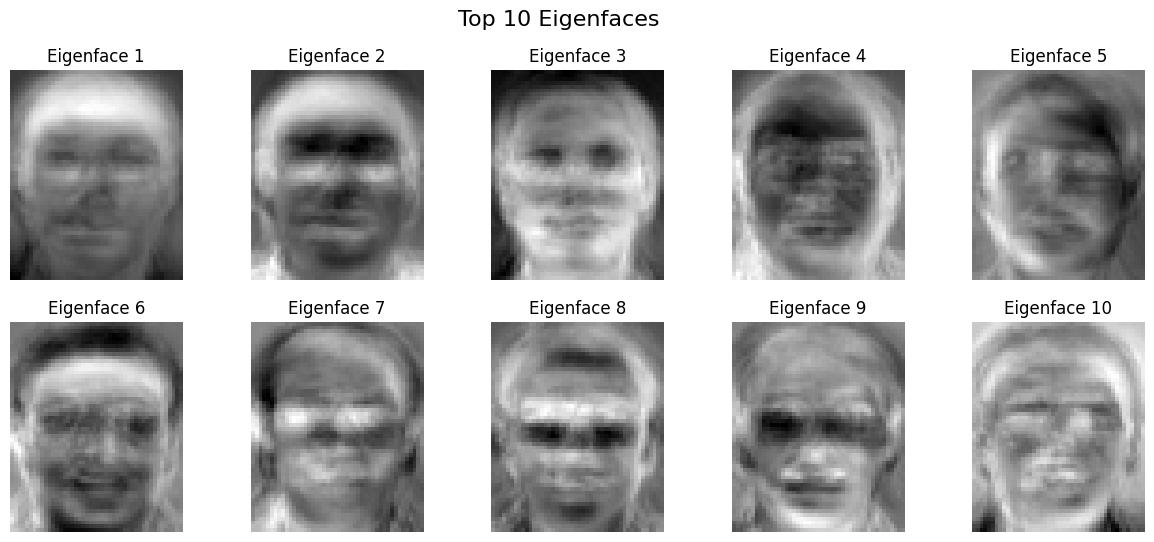

In [139]:
v_show = v.T.reshape(components, 56, 46)
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Top 10 Eigenfaces",font={"size": 16})
for i in range(components):
    ax = axs[i//5, i%5]
    ax.imshow(v_show[i], cmap="gray")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

### **Part 12**
From the image, what do you think the first eigenvector captures? What about the
second eigenvector? Look at the original images, do you think biggest variance are capture in these
two eigenvectors?

#### **Answer**
Eigenface 1 represent mostly **`seperate the face, hair and shirt`**. It can be seen that hair has the higher positive contribution than other pixel, while the shirt is more black, but it it can maintain the whole picture structure by not focusing any point

## **PCA subspace and the face verification system**
These eigenfaces we computed serve as good directions to project our data onto in order to decrease the number of dimensions. Since we have shown in class that these eigenvectors are orthogonal (and we normalized them so that they are orthonormal), we can find the projection, $\vec{p}$, of the data onto the eigenface subspace by

$$\vec{p}=V^T(\vec{x}-\vec{\mu_x})$$

where $V$ is a matrix whose columns are the eigenvectors, $\vec{p}$. The projection values, $\vec{p}$, will serve as our new input features.

### **Part 13**
Find the projection values of all images. Keep the first $k = 10$ projection values. Repeat
the simple face verification system (like item 5 in CHAPTER02) we did earlier using these
projected values.

Calculating eigenvector of covariance matrix from eigen value of Gram matrix

In [170]:
components13 = 10
v13 = x_center.T @ eigenvectors[:, :components13]
v13 = v13/np.linalg.norm(v13, axis=0)
print(f"Shape of v13: {v13.shape}")

Shape of v13: (2576, 10)


fetch data

In [178]:
xf13_train = {}
xf13_test = {}
for people in range(num_people):
    for pose in range(num_train_pose):
        xf13_train[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf13_test[people, pose] = img_as_float(data['facedata'][people, pose])

projecting the data into the projected vector from eigen value

In [179]:
train_proj = np.zeros((num_people, num_train_pose, components13))
test_proj = np.zeros((num_people, num_test_pose, components13))

for i in range(num_people):
    for j in range(num_train_pose):
        x = xf13_train[i, j].reshape(-1)
        train_proj[i, j] = v13.T @ (x - mean_face)

for i in range(num_people):
    for j in range(num_test_pose):
        x = xf13_test[i, j].reshape(-1)
        test_proj[i, j] = v13.T @ (x - mean_face)

calculating similarity

In [180]:
sim13 = np.zeros((280,num_people,num_train_pose)) # [test figure, train person, train pose]
for num_fig,test_dict in enumerate(xf13_test):
    for check_people in range(num_people):
        for check_pose in range(num_train_pose):
            sim13[num_fig, check_people, check_pose] = similarity_matrix(test_proj[test_dict] , train_proj[check_people,check_pose])

Findind good threshold

In [187]:
num_thresholds = 1000
thresholds = np.linspace(0, 15, num_thresholds)
tpr = np.array([])
far = np.array([])


for i, t in enumerate(thresholds):
    result = face_verification(similarity=sim13, t=t)

    tpr = np.append(tpr, result['TPR'])
    far = np.append(far, result['FAR'])


Closest point:
FAR = 0.10665445665445665
TPR = 0.8928571428571429
Threshold = 5.7207207207207205


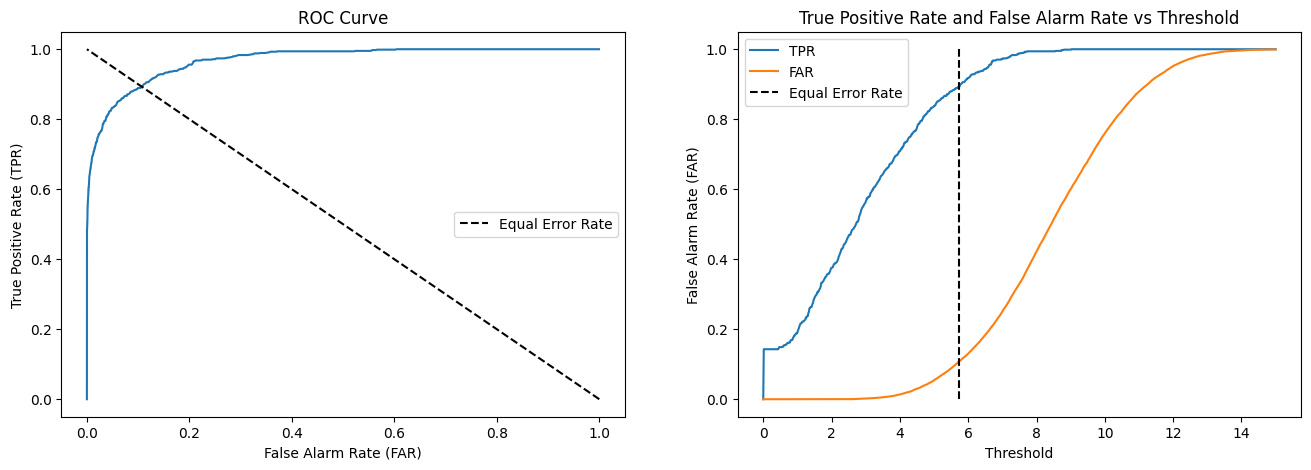

In [188]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.plot(far, tpr)
plt.plot([1, 0], [0, 1], 'k--', label='Equal Error Rate')
plt.title('ROC Curve')
plt.xlabel('False Alarm Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

dist_to_line = np.abs(tpr - (1 - far)) / np.sqrt(2)
idx = np.argmin(dist_to_line)

plt.subplot(1, 2, 2)
plt.plot(thresholds, tpr, label='TPR')
plt.plot(thresholds, far, label='FAR')
plt.plot([thresholds[idx], thresholds[idx]], [0, 1], 'k--', label='Equal Error Rate')
plt.title('True Positive Rate and False Alarm Rate vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('False Alarm Rate (FAR)')
plt.legend()

print("Closest point:")
print("FAR =", far[idx])
print("TPR =", tpr[idx])
print("Threshold =", thresholds[idx])

The graph show that the nearest point to EER line is around thrsehold=5.72, this number will selected to compare the original threshold(t=10)

#### **Answer**
the results of basic face verification are shown below!

The result of PCA with Euclidean distance metrices with t = 10

In [182]:
result = face_verification(similarity=sim13, t=10)
print(f"True Positive Rate: {result['TPR']}")
print(f"False Alarm Rate: {result['FAR']}")
print(f"TP: {result['TP']}, TN: {result['TN']}, FP: {result['FP']}, FN: {result['FN']}")
print(f"Result: {result}")

True Positive Rate: 1.0
False Alarm Rate: 0.76001221001221
TP: 840, TN: 7862, FP: 24898, FN: 0
Result: {'TP': 840, 'TN': 7862, 'FP': 24898, 'FN': 0, 'TPR': 1.0, 'FAR': 0.76001221001221}


The result of PCA with Euclidean distance metrices with t = 5.72

In [189]:
result = face_verification(similarity=sim13, t=5.72)
print(f"True Positive Rate: {result['TPR']}")
print(f"False Alarm Rate: {result['FAR']}")
print(f"TP: {result['TP']}, TN: {result['TN']}, FP: {result['FP']}, FN: {result['FN']}")
print(f"Result: {result}")

True Positive Rate: 0.8928571428571429
False Alarm Rate: 0.10662393162393162
TP: 750, TN: 29267, FP: 3493, FN: 90
Result: {'TP': 750, 'TN': 29267, 'FP': 3493, 'FN': 90, 'TPR': 0.8928571428571429, 'FAR': 0.10662393162393162}


**Compared performance**
- **Euclidean -> raw pixel : t=10** 
    - True Positive Rate: 0.9761904761904762
    - False Alarm Rate: 0.35482295482295484
    - TP: 820, TN: 21136, FP: 11624, FN: 20
    - Result: {'TP': 820, 'TN': 21136, 'FP': 11624, 'FN': 20, 'TPR': 0.9761904761904762, 'FAR': 0.35482295482295484}

- **PCA + Euclidean -> dimensionality reduction : t=10** 
    - True Positive Rate: 1.0
    - False Alarm Rate: 0.76001221001221
    - TP: 840, TN: 7862, FP: 24898, FN: 0
    - Result: {'TP': 840, 'TN': 7862, 'FP': 24898, 'FN': 0, 'TPR': 1.0, 'FAR': 0.76001221001221}

- **PCA + Euclidean -> dimensionality reduction : t=5.72** 
    - True Positive Rate: 0.8928571428571429
    - False Alarm Rate: 0.10662393162393162
    - TP: 750, TN: 29267, FP: 3493, FN: 90
    - Result: {'TP': 750, 'TN': 29267, 'FP': 3493, 'FN': 90, 'TPR': 0.8928571428571429, 'FAR': 0.10662393162393162}

**Summary Table**

| Method        | TPR   | FAR     |
| ------------- | ----- | ------- |
| Raw Pixel | 0.976 | 0.355   |
| PCA (t=10)    | 1.000 | 0.760   |
| PCA (t=5.72)  | 0.893 | 0.107   |

- The `raw pixel method achieves a high TPR of 0.976 but also a high FAR of 0.355`, meaning many false matches occur. `PCA with the same threshold (t = 10) gives perfect TPR (1.000) but an extremely high FAR of 0.760`, showing that the model becomes too permissive due to compressed feature space. **`After tuning the threshold to t = 5.72, PCA reduces FAR significantly to 0.107 while maintaining a reasonable TPR of 0.893. Therefore, PCA with a proper threshold provides a better trade-off between detection and false alarms`**.


---

One of the usage for PCA is compression. Using the project values, we can reconstruct the original
image. This can be done by

$$\vec{x}=\vec{\mu_x}+V\vec{p}$$

where $\vec{x'}$, is the reconstructed image.
We can compute the error from such reconstruction by computing the Mean Square Error (MSE)

$$MSE=\sum^N_{i=1}{\frac{1}{N}(x_i-x_i')}$$

where $N$ is the dimension of the original input.

### **Part 14**
Reconstruct the first image using this procedure. Use k = 10, what is the MSE?

In [191]:
components14 = 10
v14 = x_center.T @ eigenvectors[:, :components14]
v14 = v14/np.linalg.norm(v14, axis=0)
print(f"Shape of v14: {v14.shape}")

Shape of v14: (2576, 10)


Reconstruction

In [196]:
projected_14 = v14.T @ (xf13_train[0, 0].reshape(-1) - mean_face)
x_reconstructed = mean_face + v14 @ projected_14
x_reconstructed_image = x_reconstructed.reshape(56, 46)

#### **Answer!**

Plot the image :)

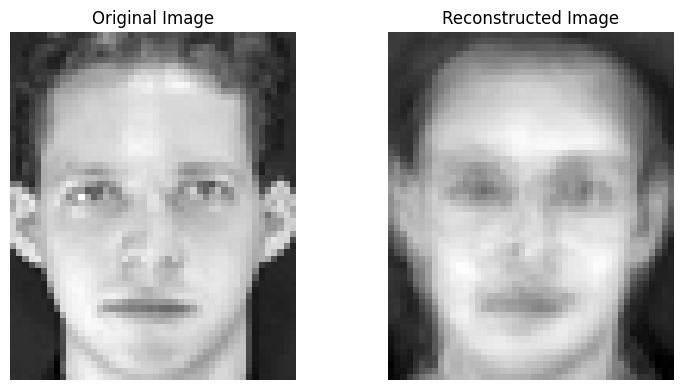

In [199]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(xf13_train[0, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(x_reconstructed_image, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")
plt.tight_layout()
plt.show()

Calculating the score

In [201]:
mse = np.sum((xf13_train[0, 0].reshape(-1) - x_reconstructed)**2) / xf13_train[0, 0].reshape(-1).shape[0]
print(f"Mean Squared Error: {mse:.4e}")

Mean Squared Error: 6.1483e-03


#### **Answer**
`MSE error` between original image and recontruction image is around: **`6.1483e-03`**

---

## **Summary**

PCA reduces dimensionality by capturing the most important information in the data, which is defined by variance. It decomposes the principal components from the covariance matrix using eigenvectors and ranks them according to their corresponding eigenvalues.

For image data, where the number of features is very large, it is more efficient to compute eigenvalues using alternative methods such as the Gram matrix or Singular Value Decomposition (SVD). The rank of the matrix depends on the minimum of the number of samples and features.

By leveraging the relationship between the dataset and the Gram matrix, we can efficiently compute the eigenvectors of the covariance matrix. Using these eigenvectors, we project the original data into a lower-dimensional space that still preserves most of the important information.

Finally, the original images can be approximately reconstructed from this reduced representation. Although the reconstructed images are not identical to the originals, they are able to retain the main facial structures.